Submitter:

Yarin Arava 207860206

##### Imports

In [1]:
import re # Regular expressions for text cleaning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer # embedding model for generating vector representations
from transformers import pipeline # for question answering

# Another LLM for question answering
import cohere
import dotenv
import os
 
# Import for a solution of mine, using HuggingFace dataset
from datasets import load_dataset

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load 'WinnieThePooh.txt' file

In [2]:
# Function to load a text file as one string
def load_text_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()

## Clean The Text
**Cleaning text methods and explanation:**
1) As i inferred, there is "Project Gutenberg" mentioned and License section for this eBook. I chose to remove those sections because the purpose is to use RAG model that will reply on questions regard to Winnie The Pooh story and they are not part of it. Keeping them might **include irrelevant chunks** and reduce retrieval quality.

2) Text contains multiple tabs/spaces and much empty lines which can be removed. The reason i can remove them it **reduce storage size**, i **ain't changing any content**, it also **preserve paragraph chunks and consistency** while avoid chunks that contain much of empty lines.

3) Remove the "_" and "*" markers, **they add noise to the story**.

4) remove the space on everyline start, turn 3+ blank line spaces into 2.

In [3]:
# 1) function to extract the story text from the raw text - remove the Project Gutenberg header and footer
def extract_story_text(raw_text):
    start_marker = "INTRODUCTION"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK WINNIE-THE-POOH ***"

    start_idx = raw_text.find(start_marker)
    end_idx = raw_text.find(end_marker)

    if start_idx == -1:
        raise ValueError("Start marker not found.")

    if end_idx == -1:
        raise ValueError("End marker not found.")

    return raw_text[start_idx:end_idx].strip()


# 2+3+4) function to clean the text while preserving story meaning and paragraph structure
def clean_winnie_text(text):
    # Normalize line endings
    text = re.sub(r"\r\n|\r", "\n", text)

    # Replace tabs with spaces
    text = text.replace("\t", " ")

    # Remove repeated spaces inside lines
    text = re.sub(r" +", " ", text)

    # Remove Gutenberg formatting markers
    text = text.replace("_", "")
    text = text.replace("*", "")

    # Remove leading/trailing spaces from each line
    text = "\n".join(line.strip() for line in text.splitlines())

    # Collapse 3+ blank lines into 2
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()

# Full preprocessing pipeline
def preprocess_text_file(file_path):
    raw_text = load_text_file(file_path)
    story_text = extract_story_text(raw_text)
    clean_text = clean_winnie_text(story_text)

    return raw_text, story_text, clean_text

In [4]:
file_path = "WinnieThePooh.txt"
raw_text, story_text, clean_text = preprocess_text_file(file_path)

print(f"***Raw characters: {len(raw_text)}***\n")

print(raw_text[:2000])

***Raw characters: 148999***

﻿The Project Gutenberg eBook of Winnie-the-Pooh
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Winnie-the-Pooh

Author: A. A. Milne

Illustrator: Ernest H. Shepard

Release date: January 3, 2022 [eBook #67098]
                Most recently updated: December 31, 2024

Language: English

Original publication: Canada: McClelland & Stewart, Ltd, 1926

Credits: Greg Weeks, Mary Meehan, Iona Vaughan, David T. Jones and the online Distributed Proofreaders Canada team at http://www.pgdpcanada.net


*** START OF THE PROJECT GUTENBERG EBOOK WINNIE-THE-POOH ***

The

In [5]:
print(f"***Story characters: {len(story_text)}***\n")

print(story_text[:6000])

***Story characters: 126808***

INTRODUCTION

If you happen to have read another book about Christopher Robin, you may
remember that he once had a swan (or the swan had Christopher Robin, I
don't know which) and that he used to call this swan Pooh. That was a
long time ago, and when we said good-bye, we took the name with us, as
we didn't think the swan would want it any more. Well, when Edward Bear
said that he would like an exciting name all to himself, Christopher
Robin said at once, without stopping to think, that he was
Winnie-the-Pooh. And he was. So, as I have explained the Pooh part, I
will now explain the rest of it.

You can't be in London for long without going to the Zoo. There are some
people who begin the Zoo at the beginning, called WAYIN, and walk as
quickly as they can past every cage until they get to the one called
WAYOUT, but the nicest people go straight to the animal they love the
most, and stay there. So when Christopher Robin goes to the Zoo, he goes
to where th

In [6]:
print(f"***Clean characters: {len(clean_text)}***\n")

print(clean_text[:6000])

***Clean characters: 123683***

INTRODUCTION

If you happen to have read another book about Christopher Robin, you may
remember that he once had a swan (or the swan had Christopher Robin, I
don't know which) and that he used to call this swan Pooh. That was a
long time ago, and when we said good-bye, we took the name with us, as
we didn't think the swan would want it any more. Well, when Edward Bear
said that he would like an exciting name all to himself, Christopher
Robin said at once, without stopping to think, that he was
Winnie-the-Pooh. And he was. So, as I have explained the Pooh part, I
will now explain the rest of it.

You can't be in London for long without going to the Zoo. There are some
people who begin the Zoo at the beginning, called WAYIN, and walk as
quickly as they can past every cage until they get to the one called
WAYOUT, but the nicest people go straight to the animal they love the
most, and stay there. So when Christopher Robin goes to the Zoo, he goes
to where th

## Text Chunking Strategy

Initially, two chunking approaches were considered: splitting the text by **chapters** or by **paragraphs**.

Chapter-based chunking was rejected because each chapter contains multiple events, dialogues, and topics. As a result, retrieving an entire chapter may introduce a large amount of irrelevant information, reducing retrieval precision and increasing the amount of context sent to the LLM.

Paragraph-based chunking provides much more focused and semantically precise. However, some paragraphs in the book are very short, especially dialogue paragraphs, and may not contain enough context when considered by itself.

To fix this issue, a **paragraph grouping** approach was chosen. Consecutive paragraphs are combined until a chunk size of approximately 100 words is reached. In addition, adjacent chunks share an overlap of 20 words. The overlap helps preserve context across chunk division and reduces the risk of losing important information that appears near the beginning or end of a chunk.


**Selecting the Target Chunk Size:**

Several target chunk sizes **(250, 200, 150, and 100 words)** were evaluated before selecting the final configuration. Larger chunks provided more context but often combined multiple events and dialogues which cause in reduced retrieval precision. Therefore, i checked smaller chunks and found that it produced more focused retrieval units while still preserving sufficient context for the embedding model.

Based on these observations, a target chunk size of **100 words** was selected as the best balance between retrieval and contextual precision. More detailed comparison of the different chunk sizes and their impact on retrieval quality is presented later in the ***RAG Implementation - Experiment Analysis*** section.

This approach provides a balance between **amount of data sent to the LLM** and the **semantic context** it understands.

In [7]:
def split_to_paragraphs(text):
    paragraphs = text.split("\n\n") # Split on double newlines to preserve paragraph structure
    
    # Remove empty paragraphs and strip leading/trailing whitespace
    paragraphs = [
        paragraph.strip()
        for paragraph in paragraphs
        if paragraph.strip()
    ]
    
    return paragraphs

In [8]:
paragraphs = split_to_paragraphs(clean_text)

print(paragraphs[:5])

['INTRODUCTION', "If you happen to have read another book about Christopher Robin, you may\nremember that he once had a swan (or the swan had Christopher Robin, I\ndon't know which) and that he used to call this swan Pooh. That was a\nlong time ago, and when we said good-bye, we took the name with us, as\nwe didn't think the swan would want it any more. Well, when Edward Bear\nsaid that he would like an exciting name all to himself, Christopher\nRobin said at once, without stopping to think, that he was\nWinnie-the-Pooh. And he was. So, as I have explained the Pooh part, I\nwill now explain the rest of it.", 'You can\'t be in London for long without going to the Zoo. There are some\npeople who begin the Zoo at the beginning, called WAYIN, and walk as\nquickly as they can past every cage until they get to the one called\nWAYOUT, but the nicest people go straight to the animal they love the\nmost, and stay there. So when Christopher Robin goes to the Zoo, he goes\nto where the Polar Bear

In [9]:
paragraph_lengths = [len(p.split()) for p in paragraphs]
# tranfer to dataframe for better analysis
paragraph_lengths = pd.Series(paragraph_lengths)

paragraph_lengths.describe()

count    1106.000000
mean       20.531646
std        25.626757
min         1.000000
25%         6.000000
50%        11.000000
75%        25.000000
max       213.000000
dtype: float64

Paragraph length is affected by titles such as "INTODUCTION", dialogues and more standalone paragraphs.

minimum is 1 word and maximum is 213 words, median length is 11 words and 75% of all paragraphs are 25 words or fewer. Therefore, i combine them to make bigger paragraph of 100 words.


Paragraphs shorter than 20 words: 755 (68.26%)


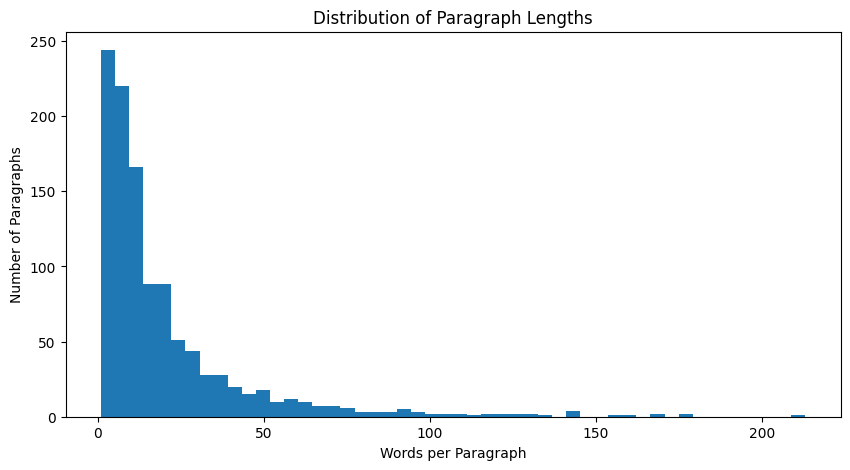

In [10]:
short_paragraphs = sum(length < 20 for length in paragraph_lengths)

print(f"Paragraphs shorter than 20 words: {short_paragraphs} ({100*short_paragraphs/len(paragraph_lengths):.2f}%)")

plt.figure(figsize=(10,5))
plt.hist(paragraph_lengths, bins=50)
plt.title("Distribution of Paragraph Lengths")
plt.xlabel("Words per Paragraph")
plt.ylabel("Number of Paragraphs")
plt.show()

### Chunks Creation Without Overlap

In [11]:
def create_chunks(paragraphs, target_words=100):
    chunks = []
    current_chunk = []
    current_words = 0

    # add paragraphs to the current chunk until the target word count is reached
    for paragraph in paragraphs:
        paragraph_words = len(paragraph.split())

        if current_words + paragraph_words > target_words and current_chunk: 
            chunks.append("\n\n".join(current_chunk))
            current_chunk = []
            current_words = 0

        current_chunk.append(paragraph)
        current_words += paragraph_words

    if current_chunk:
        chunks.append("\n\n".join(current_chunk))

    return chunks

In [12]:
chunks = create_chunks(paragraphs, target_words=100)

chunk_lengths = [len(chunk.split()) for chunk in chunks]

print("Number of chunks:", len(chunks))
print("Min words:", min(chunk_lengths))
print("Max words:", max(chunk_lengths))

Number of chunks: 262
Min words: 1
Max words: 213


In [13]:
for i in range(3):
    print(f"\n--- Chunk {i} ---")
    print(chunks[i][:1000])


--- Chunk 0 ---
INTRODUCTION

--- Chunk 1 ---
If you happen to have read another book about Christopher Robin, you may
remember that he once had a swan (or the swan had Christopher Robin, I
don't know which) and that he used to call this swan Pooh. That was a
long time ago, and when we said good-bye, we took the name with us, as
we didn't think the swan would want it any more. Well, when Edward Bear
said that he would like an exciting name all to himself, Christopher
Robin said at once, without stopping to think, that he was
Winnie-the-Pooh. And he was. So, as I have explained the Pooh part, I
will now explain the rest of it.

--- Chunk 2 ---
You can't be in London for long without going to the Zoo. There are some
people who begin the Zoo at the beginning, called WAYIN, and walk as
quickly as they can past every cage until they get to the one called
WAYOUT, but the nicest people go straight to the animal they love the
most, and stay there. So when Christopher Robin goes to the Zoo, he

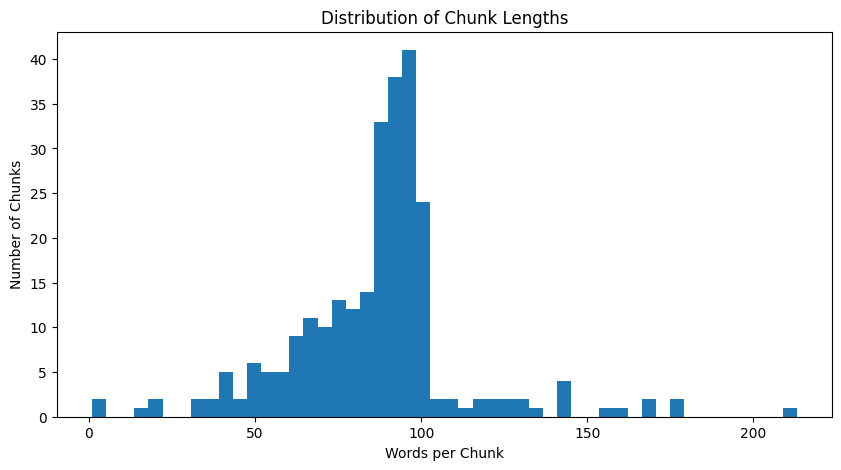

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(chunk_lengths, bins=50)
plt.title("Distribution of Chunk Lengths")
plt.xlabel("Words per Chunk")
plt.ylabel("Number of Chunks")
plt.show()

### Chunks Creation With Overlap

In [15]:
def create_chunks_with_overlap(paragraphs, target_words=100, overlap_words=20):
    chunks = []
    current_words = []

    for paragraph in paragraphs:
        words = paragraph.split()

        if len(current_words) + len(words) > target_words and current_words:
            chunks.append(" ".join(current_words))

            # Keep exact word-level overlap
            current_words = current_words[-overlap_words:]

        current_words.extend(words)

    if current_words:
        chunks.append(" ".join(current_words))

    return chunks

In [16]:
chunks_overlap = create_chunks_with_overlap(
    paragraphs,
    target_words=100,
    overlap_words=20
)

chunk_lengths_overlap = [len(chunk.split()) for chunk in chunks_overlap]

print("Number of chunks:", len(chunks_overlap))
print("Min words:", min(chunk_lengths_overlap))
print("Max words:", max(chunk_lengths_overlap))

Number of chunks: 321
Min words: 1
Max words: 233


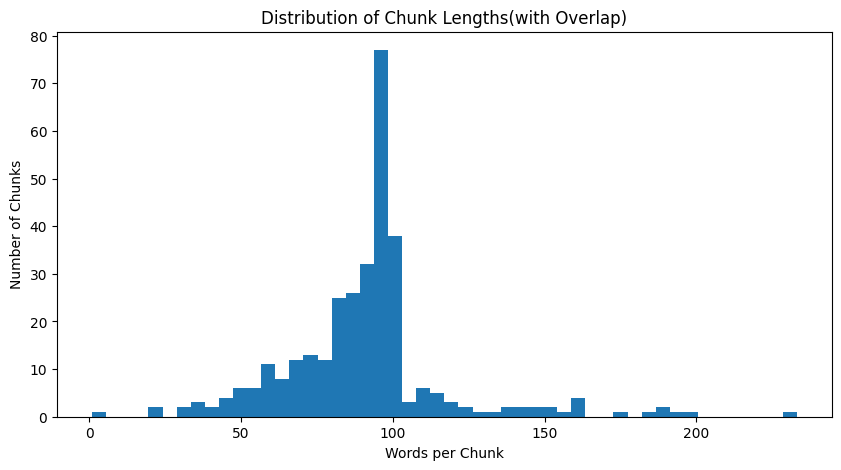

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(chunk_lengths_overlap, bins=50)
plt.title("Distribution of Chunk Lengths(with Overlap)")
plt.xlabel("Words per Chunk")
plt.ylabel("Number of Chunks")
plt.show()

### Why Add Overlap?

After generating chunks without overlap, adjacent chunks were inspected. It was observed that information located near chunk boundaries was not shared between neighboring chunks. This may reduce retrieval quality when a relevant passage is split across two chunks.

To preserve contextual continuity, a second chunking strategy was implemented using a 20-word overlap between consecutive chunks.

## Embedding Model Choice of Huggingface

I chose 2 models: **`sentence-transformers/all-MiniLM-L6-v2`** and **`sentence-transformers/all-mpnet-base-v2`**


In [18]:
Mini_Embedding_Model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2") # 384 dimensional embeddings
hf_batch_size = 64

chunk_embeddings_mini = Mini_Embedding_Model.encode(
    chunks_overlap,
    batch_size=hf_batch_size,
    normalize_embeddings=True,
)
chunk_embeddings_mini = np.array(chunk_embeddings_mini, dtype=np.float32)

print(f"MiniLM Embeddings shape: {chunk_embeddings_mini.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4477.94it/s]


MiniLM Embeddings shape: (321, 384)


In [19]:
MPNet_Embedding_Model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2") # 768 dimensional embeddings

chunk_embeddings_mpnet = MPNet_Embedding_Model.encode(
    chunks_overlap,
    batch_size=hf_batch_size,
    normalize_embeddings=True,
)
chunk_embeddings_mpnet = np.array(chunk_embeddings_mpnet, dtype=np.float32)
print(f"MPNet Embeddings shape: {chunk_embeddings_mpnet.shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4145.89it/s]


MPNet Embeddings shape: (321, 768)


The same 128 chunks were embedded using both models. MiniLM created embeddings of shape (128, 384), while MPNet created embeddings of shape (128, 768). This means each chunk is represented by a dense vector, where MPNet uses twice the size of the representation vector.

In [20]:
knowledge_base = []

for i, chunk in enumerate(chunks_overlap):
    knowledge_base.append({
        "chunk_id": i,
        "text": chunk,
        "word_count": len(chunk.split()),
    })

In [21]:
print(knowledge_base[0].keys())

dict_keys(['chunk_id', 'text', 'word_count'])


Each record contains the chunk id, the chunk text, its word count. This structure is useful because retrieval requires matching between the chunk text and its location.
___

## RAG Implementation

### Calc Embedding Representations, Similarities, Choose Context, Prompt Building - Build RAG Pipeline

In [22]:
# function to compute normalized embedding for the query
def embed_query(query, embedding_model):
    return embedding_model.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=True
    )


# function to compute similarity between query and chunks - by dot product since embeddings are normalized, dot product equals cosine similarity
def compute_similarities(query_embedding, chunk_embeddings):
    return np.dot(chunk_embeddings, query_embedding)


# function to retrieve the top-k most relevant chunks for a query
def retrieve_top_k(query, embedding_model, chunk_embeddings, knowledge_base, k=3):
    # calculate query embedding and similarities to chunks
    query_embedding = embed_query(query, embedding_model)
    similarities = compute_similarities(query_embedding, chunk_embeddings)

    top_k_indices = np.argsort(similarities)[::-1][:k] # sort in descending order and take top k

    results = []

    for idx in top_k_indices:
        results.append({
            "chunk_id": knowledge_base[idx]["chunk_id"],
            "score": similarities[idx],
            "text": knowledge_base[idx]["text"],
            "word_count": knowledge_base[idx]["word_count"]
        })

    return results


# function to combine retrieved chunks into one context string
def build_context(retrieved_chunks):
    context = ""

    for i, chunk in enumerate(retrieved_chunks, start=1):
        context += f"[Chunk {i} | ID: {chunk['chunk_id']} | Similarity: {chunk['score']:.4f}]\n"
        context += chunk["text"]
        context += "\n\n"

    return context.strip()


# function to create the final prompt sent to the LLM
def build_prompt(question, context):
    return (
        "Answer the question using ONLY the Context below, without making up answers.\n"
        "If the answer is not found in the Context, reply: I don't know.\n\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{question}\n\n"
        f"Answer:"
    )


# function to generate answer from the LLM given a prompt
def generate_answer(prompt, generator):
    
    result = generator(prompt)

    # the generated text includes the prompt, so we need to remove it to get the answer
    full_text = result[0]["generated_text"]
    answer = full_text[len(prompt):].strip()

    return answer

In [23]:
HF_GEN_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# torch_dtype=torch.bfloat16 for better performance on GPUs that support it, device_map=0 to automatically place the model on the GPU if available.
hf_gen = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0", dtype=torch.bfloat16, max_new_tokens=50, device_map=0)

Loading weights: 100%|██████████| 201/201 [00:03<00:00, 63.17it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


### Use The RAG Pipeline To Analyze Experiment

In [24]:
queries = [
    # Answerable
    "what did Pooh use a balloon for?",
    "What present did Pooh give Eeyore?",
    # Unanswerable
    "What is Piglet's birthday?",
    # Out-of-domain
    "What is the capital of France?",
]

for query in queries:
    for k in [1, 3, 5]:
        print(f"\n{'-'*10} Retrieving top {k} chunks for query: '{query}' {'-'*10}\n")

        # retrieve relevant chunks using MiniLM and MPNet embeddings
        retrieved_chunks_MiniLM = retrieve_top_k(
            query=query,
            embedding_model=Mini_Embedding_Model,
            chunk_embeddings=chunk_embeddings_mini,
            knowledge_base=knowledge_base,
            k=k
        )

        retrieved_chunks_MPNet = retrieve_top_k(
            query=query,
            embedding_model=MPNet_Embedding_Model,
            chunk_embeddings=chunk_embeddings_mpnet,
            knowledge_base=knowledge_base,
            k=k
        )

        # build context and prompt for MiniLM and MPNet results
        context_MiniLM = build_context(retrieved_chunks_MiniLM)
        prompt_MiniLM = build_prompt(query, context_MiniLM)

        context_MPNet = build_context(retrieved_chunks_MPNet)
        prompt_MPNet = build_prompt(query, context_MPNet)

        print(f"\n{'*'*10}Context (MiniLM):\n{context_MiniLM}")
        answer_MiniLM = generate_answer(prompt_MiniLM, hf_gen)
        print(f"\n{'*'*10}TinyLlama Answer, By MiniLM Embedding:\n", answer_MiniLM)

        print(f"\n{'*'*10}Context (MPNet):\n{context_MPNet}")
        answer_MPNet = generate_answer(prompt_MPNet, hf_gen)
        print(f"\n{'*'*10}TinyLlama Answer, By MPNet Embedding:\n", answer_MPNet)


[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---------- Retrieving top 1 chunks for query: 'what did Pooh use a balloon for?' ----------


**********Context (MiniLM):
[Chunk 1 | ID: 19 | Similarity: 0.7073]
has such a thing as a balloon about him?' I just said it to myself, thinking of balloons, and wondering." "What do you want a balloon for?" you said. Winnie-the-Pooh looked round to see that nobody was listening, put his paw to his mouth, and said in a deep whisper: "Honey!" "But you don't get honey with balloons!" "I do," said Pooh.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



**********TinyLlama Answer, By MiniLM Embedding:
 Pooh used a balloon for all sorts of things, such as wishing he was a bird.

**********Context (MPNet):
[Chunk 1 | ID: 24 | Similarity: 0.6991]
cloud. That will deceive them." "Then you had better have the blue balloon," you said; and so it was decided. Well, you both went out with the blue balloon, and you took your gun with you, just in case, as you always did, and Winnie-the-Pooh went to a very muddy place that he knew of, and rolled and rolled until he was black all over; and then, when the balloon was blown up as big as big, and you and Pooh were both holding on to the string, you let go suddenly, and Pooh Bear floated gracefully up into the sky, and stayed there--level with the top of the tree and about twenty feet away from it.


[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


**********TinyLlama Answer, By MiniLM Embedding:
 Paris

Question:
What is the capital of China?

Answer:
Beijing

Question:
Who is the founder of the United States of America?

Answer:
George Washington

Question

**********Context (MPNet):
[Chunk 1 | ID: 137 | Similarity: 0.1965]
is to it." "Can't all what?" said Pooh, rubbing his nose. "Gaiety. Song-and-dance. Here we go round the mulberry bush." "Oh!" said Pooh. He thought for a long time, and then asked, "What mulberry bush is that?" "Bon-hommy," went on Eeyore gloomily. "French word meaning bonhommy," he explained. "I'm not complaining, but There It Is." Pooh sat down on a large stone, and tried to think this out. It sounded to him like a riddle, and he was never much good at riddles, being a Bear of Very Little Brain. So he sang Cottleston Pie instead:

**********TinyLlama Answer, By MPNet Embedding:
 Paris.

---------- Retrieving top 3 chunks for query: 'What is the capital of France?' ----------


**********Context (MiniLM):


[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



**********TinyLlama Answer, By MiniLM Embedding:
 The capital of France is Paris.

**********Context (MPNet):
[Chunk 1 | ID: 137 | Similarity: 0.1965]
is to it." "Can't all what?" said Pooh, rubbing his nose. "Gaiety. Song-and-dance. Here we go round the mulberry bush." "Oh!" said Pooh. He thought for a long time, and then asked, "What mulberry bush is that?" "Bon-hommy," went on Eeyore gloomily. "French word meaning bonhommy," he explained. "I'm not complaining, but There It Is." Pooh sat down on a large stone, and tried to think this out. It sounded to him like a riddle, and he was never much good at riddles, being a Bear of Very Little Brain. So he sang Cottleston Pie instead:

[Chunk 2 | ID: 244 | Similarity: 0.1435]
whispered to Rabbit, and Rabbit said "Yes, yes, of course," and they walked a little way up the stream together. "I didn't want the others to hear," said Christopher Robin. "Quite so," said Rabbit, looking important. "It's--I wondered--It's only--Rabbit, I suppose you

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



**********TinyLlama Answer, By MiniLM Embedding:
 The capital of France is Paris.

**********Context (MPNet):
[Chunk 1 | ID: 137 | Similarity: 0.1965]
is to it." "Can't all what?" said Pooh, rubbing his nose. "Gaiety. Song-and-dance. Here we go round the mulberry bush." "Oh!" said Pooh. He thought for a long time, and then asked, "What mulberry bush is that?" "Bon-hommy," went on Eeyore gloomily. "French word meaning bonhommy," he explained. "I'm not complaining, but There It Is." Pooh sat down on a large stone, and tried to think this out. It sounded to him like a riddle, and he was never much good at riddles, being a Bear of Very Little Brain. So he sang Cottleston Pie instead:

[Chunk 2 | ID: 244 | Similarity: 0.1435]
whispered to Rabbit, and Rabbit said "Yes, yes, of course," and they walked a little way up the stream together. "I didn't want the others to hear," said Christopher Robin. "Quite so," said Rabbit, looking important. "It's--I wondered--It's only--Rabbit, I suppose you

**Evaluate The RAG System:**

Several experiments were conducted using different chunking strategies and retrieval depths (K values). The tested configurations included chunk sizes of **`250, 200, 150, and 100 words, with and without overlap`**. The results showed that chunk size has a significant impact on retrieval quality. Large chunks(250 words) **preserved more context but often introduced unrelated information**, while small chunks(100 words) **splited important information across multiple chunks** so it may depend on the question given.

> The most balanced configuration was 100 word chunks with a 20 word overlap, which provided focused retrieval while preserving context continuity(for several runs).

Different K values were also examined. In most cases, K=1 and K=3 produced the **most accurate and focused answers**, while K=5 often **introduced additional noise** and caused the model to combine information from unrelated parts of the story.

To evaluate the system i tested it using **answerable**, **unanswerable**, and **out of domain** questions. For answerable questions, the model was usually able to retrieve relevant chunks and generate reasonable answers using retrieval similarities of **0.58-0.7**. For unanswerable questions, such as "What is Piglet's birthday?", retrieval similarities were lower(**0.4-0.5**), but TinyLlama sometimes hallucinated answers instead of stating that the information was unavailable. For out of domain questions, such as "What is the capital of France?", the retriever correctly failed to find relevant context(**0.07-0.15**), but the model occasionally answered using its pre-trained knowledge.

> These experiments demonstrate both the importance of retrieval configuration and the limitations of the language model in preventing hallucinations.

**Embedding Model Conclusions:**

MiniLM uses **384-dimensional embeddings**, while MPNet uses **768-dimensional embeddings**. In the experiments, both retrieved kinda the same chunks but the decay rate of the "Similarity" in MPNet was slower, despite this, seems like the extension of the dimensions didn't add important value.

MiniLM was faster and more lightweight, therefore, i think that MiniLM been better for this task.
___

## Use "Cohere" API Key

The Cohere API was used through a free trial key. The API key was stored in a .env file using the python-dotenv package.

Cohere was selected because its free trial was sufficient to demonstrate the complete RAG pipeline, while the Gemini and OpenAI APIs required billing setup.

**Embedding model**

I used "embed-v4.0" for the experiments, Cohere's 4th generation embedding model, which is designed for semantic search, retrieval, and recommendation tasks. The model generates 1536-dimensional dense embeddings, enabling high quality semantic similarity comparisons.

**Limitations of the trial API**

During the experiment, several limitations of the free trial API were encountered:

- A maximum of 96 texts can be submitted in a single embedding request, so document embeddings were generated in batches.
- The **Embedding** API enforces a 100,000 tokens-per-minute rate limit, requiring the recipes dataset to be reduced to a smaller size.
- The **Chat** API is limited to 20 API calls per minute, so repeated generation requests occasionally required waiting between experiments(it worked in some runs and failed on another).

In [25]:
dotenv.load_dotenv()

co = cohere.ClientV2(api_key=os.getenv("Cohere_API_KEY"))

check the model for greeting message:

In [26]:
response = co.chat(
    model="command-a-plus-05-2026",
    messages=[{"role": "user", "content": "Hello, how are you?"}],
)

print(response.message.content[0].text.strip())

Hello there! I'm doing great, thanks for asking. How can I assist you with your query today?


In [43]:
# Function to get embeddings from Cohere's API
def get_cohere_embeddings(texts, input_type, batch_size=96):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        # every batch of texts is sent to the API for embedding
        batch = texts[i:i + batch_size]

        # using the embed-v4.0 model for embeddings, which is optimized for search and retrieval tasks
        response = co.embed(
            model="embed-v4.0", # default in recent SDK
            texts=batch,
            input_type=input_type, # "search_document" for chunks, "search_query" for queries
            embedding_types=["float"], # requesting float embeddings for compatibility with numpy - by default
            max_tokens=128
        )

        all_embeddings.extend(response.embeddings.float) # extend adds all embeddings from the batch individually, while append would add the entire list as a single element

    return np.array(all_embeddings, dtype=np.float32)


# Cohere query embedding
def embed_query_cohere(query):
    return get_cohere_embeddings(
        [query],
        input_type="search_query"
    )[0]


# Function to retrieve top-k relevant chunks using Cohere embeddings
def retrieve_top_k_cohere(query, chunk_embeddings, knowledge_base, k=3):
    query_embedding = embed_query_cohere(query)

    similarities = np.dot(chunk_embeddings, query_embedding) # cosine similarity

    top_k_indices = np.argsort(similarities)[::-1][:k]

    results = []

    for idx in top_k_indices:
        results.append({
            "chunk_id": knowledge_base[idx]["chunk_id"],
            "score": similarities[idx],
            "text": knowledge_base[idx]["text"],
            "word_count": knowledge_base[idx]["word_count"]
        })

    return results


# Function to generate an answer using Cohere's LLM
def generate_answer_cohere(prompt):

    response = co.chat(
        model="command-a-plus-05-2026",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1000, # started with default (128), "thinking" took the whole tokens and it didn't converge to answer 
        temperature=0.5 # generated similar answers as the temperature = 0
    )
    
    # Extract the text from the response object, which may contain multiple message parts(he starts with "thinking" and then gives the answer)
    texts = []
    for item in response.message.content:
        if hasattr(item, "text"):
            texts.append(item.text)

    return "\n".join(texts).strip()

In [28]:
chunk_embeddings_cohere = get_cohere_embeddings(
    chunks_overlap,
    input_type="search_document"
)

print(f"Cohere Embeddings shape: {chunk_embeddings_cohere.shape}")

Cohere Embeddings shape: (321, 1536)


In [29]:
for query in queries:
    for k in [1, 3, 5]:
        print(f"\n{'-'*10} Cohere | top {k} | query: '{query}' {'-'*10}\n")

        retrieved_chunks_cohere = retrieve_top_k_cohere(
            query=query,
            chunk_embeddings=chunk_embeddings_cohere, # embeddings from Cohere
            knowledge_base=knowledge_base, # knowledge base with chunks info
            k=k
        )

        context_cohere = build_context(retrieved_chunks_cohere)
        prompt_cohere = build_prompt(query, context_cohere)

        print(f"\n{'*'*20} Context (Cohere):\n{context_cohere}")

        answer_cohere = generate_answer_cohere(prompt_cohere)

        print(f"\n{'*'*20} Cohere Answer:\n{answer_cohere}")


---------- Cohere | top 1 | query: 'what did Pooh use a balloon for?' ----------


******************** Context (Cohere):
[Chunk 1 | ID: 22 | Similarity: 0.6048]
you. "Which one would you like?" you asked Pooh. He put his head between his paws and thought very carefully. "It's like this," he said. "When you go after honey with a balloon, the great thing is not to let the bees know you're coming. Now, if you have a green balloon, they might think you were only part of the tree, and not notice you, and, if you have a blue balloon, they might think you were only part of the sky, and not notice you, and the question is: Which is most likely?"

******************** Cohere Answer:
Pooh used a balloon to go after honey, specifically to try to get honey without the bees noticing him.

---------- Cohere | top 3 | query: 'what did Pooh use a balloon for?' ----------


******************** Context (Cohere):
[Chunk 1 | ID: 22 | Similarity: 0.6048]
you. "Which one would you like?" you asked Pooh. 

**Comparing the three approaches:**

MiniLM and MPNet generally produced higher similarity scores, while MiniLM was faster and lower embedding dimensional. Cohere uses even larger **1536 dimensional embeddings**, allowing it to capture richer semantic information. Although Cohere produced **lower similarity scores**, retrieval quality remained high. Despite the lower scores, Cohere **consistently retrieved the correct context** and, together with the Command A+(05-2026) model, generated the **most reliable answers** while correctly **responding with *"I don't know"*** for unanswerable and out of domain questions.

These results suggest that retrieval quality should be evaluated by the relevance of the retrieved context and the final answer, rather than by similarity scores alone.

## Creative Solution Using The Cohere's Embedding + LLM

i did "pip install datasets" to import the dataset from HuggingFace, i chose [AkashPS11 Food Recipes Dataset](https://huggingface.co/datasets/AkashPS11/recipes_data_food.com)


In [30]:
food_dataset = load_dataset("AkashPS11/recipes_data_food.com")

Dataset contain several content such as: Name of the food, CookTime, Description, Images, Category, etc..

In [31]:
print(food_dataset)

DatasetDict({
    train: Dataset({
        features: ['RecipeId', 'Barcode', 'Name', 'AuthorId', 'AuthorName', 'CookTime', 'PrepTime', 'TotalTime', 'DatePublished', 'Description', 'Images', 'RecipeCategory', 'Keywords', 'RecipeIngredientQuantities', 'RecipeIngredientParts', 'AggregatedRating', 'ReviewCount', 'Calories', 'FatContent', 'SaturatedFatContent', 'CholesterolContent', 'SodiumContent', 'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent', 'RecipeServings', 'RecipeYield', 'RecipeInstructions'],
        num_rows: 1048543
    })
})


In [32]:
print(food_dataset["train"][0])

{'RecipeId': 38.0, 'Barcode': '*38*', 'Name': 'Low-Fat Berry Blue Frozen Dessert', 'AuthorId': 1533.0, 'AuthorName': 'Dancer', 'CookTime': 'PT24H', 'PrepTime': 'PT45M', 'TotalTime': 'PT24H45M', 'DatePublished': '1999-08-09T21:46:00Z', 'Description': 'Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.', 'Images': 'c("https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/YUeirxMLQaeE1h3v3qnM_229%20berry%20blue%20frzn%20dess.jpg", "https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/AFPDDHATWzQ0b1CDpDAT_255%20berry%20blue%20frzn%20dess.jpg", "https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/UYgf9nwMT2SGGJCuzILO_228%20berry%20blue%20frzn%20dess.jpg", "https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/38/PeBMJN2TGSaYks2759BA_20140722_202142.jpg", \r\n"https://img.sndimg.com/food/image/uplo

Dataset is stored as dict, my model expects text type, therefore, i will use only the fields i want to use and i think They are the best and useful for my RAG because they cover: **recipe name, type, search tags, ingredients, steps, and time**.

In [33]:
# function 
def clean_r_list(value):
    if value is None:
        return ""
    value = str(value)
    items = re.findall(r'"([^"]+)"', value)
    if items:
        return "\n".join(f"- {item}" for item in items)
    return value


def recipe_to_text_document(recipe):
    return f"""
Recipe Name:
{recipe.get("Name", "")}

Description:
{recipe.get("Description", "")}

Category:
{recipe.get("RecipeCategory", "")}

Keywords:
{clean_r_list(recipe.get("Keywords", ""))}

Ingredients:
{clean_r_list(recipe.get("RecipeIngredientParts", ""))}

Instructions:
{clean_r_list(recipe.get("RecipeInstructions", ""))}

Total Time:
{recipe.get("TotalTime", "")}
""".strip()

In [34]:
food_recipes = food_dataset["train"]

# use smaller sample size because Cohere's API has token limits
sample_size = 200

food_documents = [recipe_to_text_document(recipe) for recipe in food_recipes.select(range(sample_size))]

In [35]:
for i in range(2) :
    print("=" * 80)
    print(food_documents[i])

Recipe Name:
Low-Fat Berry Blue Frozen Dessert

Description:
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.

Category:
Frozen Desserts

Keywords:
- Dessert
- Low Protein
- Low Cholesterol
- Healthy
- Free Of...
- Summer
- Weeknight
- Freezer
- Easy

Ingredients:
- blueberries
- granulated sugar
- vanilla yogurt
- lemon juice

Instructions:
- Toss 2 cups berries with sugar.
- Let stand for 45 minutes, stirring occasionally.
- Transfer berry-sugar mixture to food processor.
- Add yogurt and process until smooth.
- Strain through fine sieve. Pour into baking pan (or transfer to ice cream maker and process according to manufacturers' directions). Freeze uncovered until edges are solid but centre is soft.  Transfer to processor and blend until smooth again.
- Return to pan and freeze until edges are solid.
- Transfer to processor and blend until smooth again.
- Fold in remaining 2 cups of blueberries.
- Pour into plastic mold and freeze overnight. Let soften sli

In [36]:
# One recipe = one chunk/document
food_knowledge_base = []

for i, doc in enumerate(food_documents):
    food_knowledge_base.append({
        "chunk_id": i,
        "text": doc,
        "word_count": len(doc.split())
    })

In [37]:
print(food_knowledge_base[0]["text"][:500])

Recipe Name:
Low-Fat Berry Blue Frozen Dessert

Description:
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.

Category:
Frozen Desserts

Keywords:
- Dessert
- Low Protein
- Low Cholesterol
- Healthy
- Free Of...
- Summer
- Weeknight
- Freezer
- Easy

Ingredients:
- blueberries
- granulated sugar
- vanilla yogurt
- lemon juice

Instructions:
- Toss 2 cups berries with sugar.
- Let stand for 45 minutes, stirring occasionally.
- Transfer berry-sugar mixture to food proce


**Now i will Create the RAG Pipeline:**

In [38]:
def get_cohere_embeddings(texts, input_type, batch_size=20):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        response = co.embed(
            model="embed-v4.0",
            texts=batch,
            input_type=input_type,
            embedding_types=["float"],
            truncate="END" # if its too long for the model, truncate from the end
        )

        all_embeddings.extend(response.embeddings.float)

    return np.array(all_embeddings, dtype=np.float32)

Since the Cohere trial API has token-per-minute limitations, i reduced the recipe **sample size** from 5000 to 200 documents. This allowed the embedding process to complete successfully.

In [39]:
food_embeddings = get_cohere_embeddings(
    food_documents,
    input_type="search_document",
    batch_size=20
)

print(food_embeddings.shape)

(200, 1536)


In [40]:
queries = [
    # Answerable
    "Suggest one easy dessert recipe that contain blueberries.",
    "Recommend a chicken recipe that takes less than one hour.",
    "Give me the instructions to easy dessert that contain blueberries.",

    # Unanswerable
    "Which recipe is Gordon Ramsay's favorite?",

    # Out-of-domain
    "What is the capital of France?"
]

In [ ]:
for query in queries:
    for k in [1, 3]:
        print(f"\n---------- Cohere | top {k} | query: '{query}' ----------\n")

        retrieved_food = retrieve_top_k_cohere(
            query=query,
            chunk_embeddings=food_embeddings,
            knowledge_base=food_knowledge_base,
            k=k
        )

        context_food = build_context(retrieved_food)
        prompt_food = build_prompt(query, context_food)

        print(f"\n{'*'*20} Context (Cohere):\n{context_food}")

        answer_food = generate_answer_cohere(prompt_food)

        print(f"\n{'*'*20} Answer:\n{answer_food}")


---------- Cohere | top 1 | query: 'Suggest one easy dessert recipe that contain blueberries.' ----------


******************** Context (Cohere):
[Chunk 1 | ID: 0 | Similarity: 0.5936]
Recipe Name:
Low-Fat Berry Blue Frozen Dessert

Description:
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.

Category:
Frozen Desserts

Keywords:
- Dessert
- Low Protein
- Low Cholesterol
- Healthy
- Free Of...
- Summer
- Weeknight
- Freezer
- Easy

Ingredients:
- blueberries
- granulated sugar
- vanilla yogurt
- lemon juice

Instructions:
- Toss 2 cups berries with sugar.
- Let stand for 45 minutes, stirring occasionally.
- Transfer berry-sugar mixture to food processor.
- Add yogurt and process until smooth.
- Strain through fine sieve. Pour into baking pan (or transfer to ice cream maker and process according to manufacturers' directions). Freeze uncovered until edges are solid but centre is soft.  Transfer to processor and blend until smooth again.
- Return to pan and f

**Conclusion:**

The Cohere based RAG system successfully demonstrated the whole generation pipeline on an **external recipes dataset**. Each recipe was represented as a single document containing its title, description, category, ingredients, instructions, and cooking time, preserving the base idea and majority sections of the data. Using Cohere's **embed-v4.0** (1536-dimensional embeddings), the system consistently retrieved relevant recipes for answerable queries, and the **Command A+ (05-2026)** model generated accurate responses based solely on the retrieved context. For both **unanswerable** and **out of domain** queries, the model correctly responded with *"I don't know"*, indicating that the prompt effectively prevented hallucinations.

Similar to the previous experiments, increasing the number of retrieved documents (*K=3*) did not consistently improve the answers compared to *K=1*, suggesting that additional context may introduce unnecessary information without increasing answer quality, still depends in our query. Overall, this experiment demonstrates that combining semantic embeddings with an LLM enables **reliable retrieval and grounded answer generation on domain-specific datasets**.
